In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load datasets
reviews = pd.read_csv("../data/reviews.csv")
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
order_items = pd.read_csv("../data/order_items.csv")
products = pd.read_csv("../data/products.csv")
suppliers = pd.read_csv("../data/suppliers.csv")
returns = pd.read_csv("../data/returns.csv")
resellers = pd.read_csv("../data/resellers.csv")
reseller_activity = pd.read_csv("../data/reseller_activity.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Suppliers:", suppliers.shape)
print("Returns:", returns.shape)
print("Reviews:", reviews.shape)
print("Resellers:", resellers.shape)
print("Reseller Activity:", reseller_activity.shape)

Customers: (12000, 5)
Orders: (25000, 10)
Order Items: (43977, 6)
Products: (2500, 8)
Suppliers: (150, 7)
Returns: (2501, 5)
Reviews: (9503, 4)
Resellers: (1000, 8)
Reseller Activity: (17500, 6)


In [4]:
orders.head()

,order_id,reseller_id,customer_name,order_date,delivery_date,city,state,order_status,total_amount,payment_method
0,1,125,Customer_04451,2024-01-31,2024-02-06,Agra,West Bengal,Delivered,1841.90,Wallet
1,2,573,Customer_11626,2023-03-18,2023-03-27,Agra,Maharashtra,Delivered,7948.32,Wallet
2,3,620,Customer_08833,2023-07-27,2023-08-03,Jaipur,Karnataka,Delivered,2714.00,COD
3,4,674,Customer_11111,2024-01-29,2024-02-04,Indore,Telangana,Delivered,2375.94,UPI
4,5,73,Customer_10443,2023-05-25,2023-06-03,Hyderabad,West Bengal,Delivered,1620.81,Wallet


In [5]:
orders.columns

Index(['order_id', 'reseller_id', 'customer_name', 'order_date',
       'delivery_date', 'city', 'state', 'order_status', 'total_amount',
       'payment_method'],
      dtype='object')

In [6]:
order_items.head()

,order_item_id,order_id,product_id,quantity,price_sold,discount_percent
0,1,1,1053,1,1841.90,16.48
1,2,2,344,1,2139.76,20.87
2,3,2,2042,1,2825.36,6.50
3,4,2,2365,2,265.99,36.85
4,5,2,2004,1,2451.22,13.21


In [7]:
products.head()


,product_id,supplier_id,product_name,category,subcategory,cost_price,mrp,commission_percent
0,1,140,Sarees_1,Fashion,Sarees,1585.64,2846.26,20.63
1,2,100,Kids Wear_2,Fashion,Kids Wear,1834.09,3581.30,10.41
2,3,72,Womens Ethnic_3,Fashion,Womens Ethnic,705.87,1158.27,6.17
3,4,60,Sarees_4,Fashion,Sarees,1105.92,2481.16,24.48
4,5,137,Womens Ethnic_5,Fashion,Womens Ethnic,570.93,950.75,21.33


In [8]:
# ---------------------------------------------------
# SECTION 1: Basic Revenue Metrics
# Purpose:
# Validate the SQL calculations using Python.
# This ensures our dataset behaves as expected.
# ---------------------------------------------------

# Filter only delivered orders
# In e-commerce analytics, revenue is usually calculated
# only from successfully delivered orders.

delivered_orders = orders[orders["order_status"] == "Delivered"]

# Calculate Gross Merchandise Value (GMV)
# GMV = Total revenue generated by the platform

gmv = delivered_orders["total_amount"].sum()

print("Total GMV of the platform:", round(gmv, 2))

Total GMV of the platform: 76725364.53


In [9]:
# ---------------------------------------------------
# SECTION 2: Average Order Value (AOV)
# Purpose:
# Understand how much customers typically spend per order
# ---------------------------------------------------

# Average Order Value calculation

aov = delivered_orders["total_amount"].mean()

print("Average Order Value (AOV):", round(aov, 2))

Average Order Value (AOV): 3605.35


In [10]:
# ---------------------------------------------------
# SECTION 3: Monthly Revenue Trend
# Purpose:
# Understand how the platform's revenue changes over time.
# This helps identify growth patterns.
# ---------------------------------------------------

# Convert order_date column to proper datetime format
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Filter only delivered orders
delivered_orders = orders.loc[orders["order_status"] == "Delivered"].copy()
# Create a new column representing the month
delivered_orders["order_month"] = delivered_orders["order_date"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = delivered_orders.groupby("order_month")["total_amount"].sum().reset_index()

# Convert period to string for plotting
monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

# Display the first few rows
monthly_revenue.head()

,order_month,total_amount
0,2023-01,4284596.23
1,2023-02,3699135.73
2,2023-03,4481962.85
3,2023-04,4313427.09
4,2023-05,4432367.94


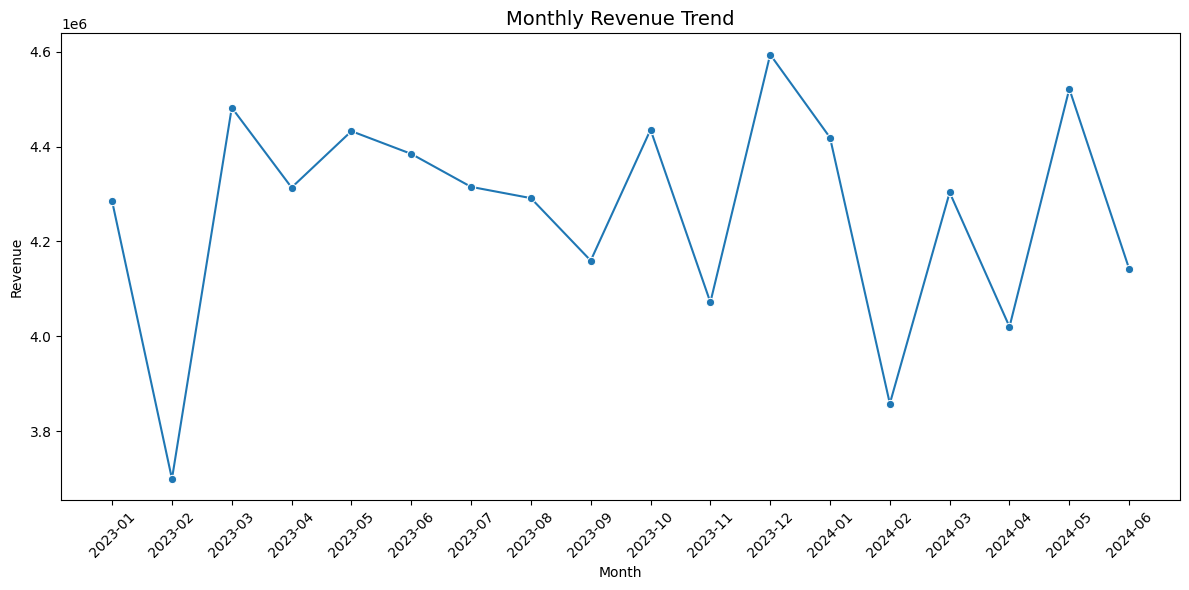

In [11]:
# ---------------------------------------------------
# SECTION 4: Monthly Revenue Visualization
# Purpose:
# Create a line chart showing how revenue changes
# month by month.
# This is a common executive dashboard metric.
# ---------------------------------------------------

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_revenue,
    x="order_month",
    y="total_amount",
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [12]:
# ---------------------------------------------------
# SECTION 5: Revenue by Product Category
# Purpose:
# Identify which product categories generate
# the most revenue for the platform.
# ---------------------------------------------------

# Step 1: Filter only delivered orders
delivered_orders = orders.loc[orders["order_status"] == "Delivered"].copy()

# Step 2: Merge orders with order_items
orders_items_merged = pd.merge(
    delivered_orders,
    order_items,
    on="order_id",
    how="inner"
)

# Step 3: Merge with products table
full_data = pd.merge(
    orders_items_merged,
    products,
    on="product_id",
    how="inner"
)

# Step 4: Calculate revenue per item
full_data["item_revenue"] = full_data["quantity"] * full_data["price_sold"]

# Step 5: Group by category
category_revenue = (
    full_data
    .groupby("category")["item_revenue"]
    .sum()
    .reset_index()
    .sort_values(by="item_revenue", ascending=False)
)

category_revenue.head()

,category,item_revenue
2,Fashion,39120148.01
3,Home & Kitchen,18918112.95
0,Beauty & Personal Care,11385123.95
1,Electronics,7301981.52


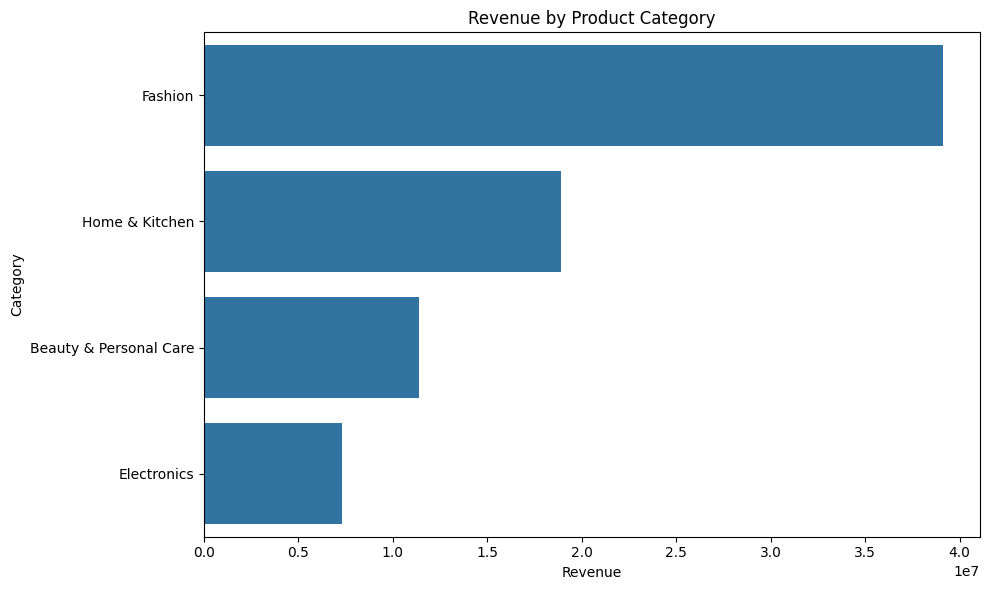

In [13]:
# ---------------------------------------------------
# SECTION 6: Category Revenue Chart
# Purpose:
# Visualize which categories contribute
# the most revenue.
# ---------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_revenue,
    x="item_revenue",
    y="category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [14]:
# ---------------------------------------------------
# SECTION 7: Top Revenue Generating Products
# Purpose:
# Identify which individual products generate
# the most revenue for the platform.
# ---------------------------------------------------

# Group revenue by product name
product_revenue = (
    full_data
    .groupby("product_name")["item_revenue"]
    .sum()
    .reset_index()
    .sort_values(by="item_revenue", ascending=False)
)

# Select top 10 products
top_products = product_revenue.head(10)

# Display result
top_products

,product_name,item_revenue
1137,Kurtis_814,122928.43
2243,T-Shirts_82,115043.16
2163,T-Shirts_430,112750.70
2187,T-Shirts_541,109769.65
314,Gadgets_2388,106763.46
333,Gadgets_2422,100003.68
563,Home Decor_1712,99653.03
738,Kids Wear_687,99439.04
2260,T-Shirts_898,98822.53
1501,Mobile Accessories_2294,97704.49


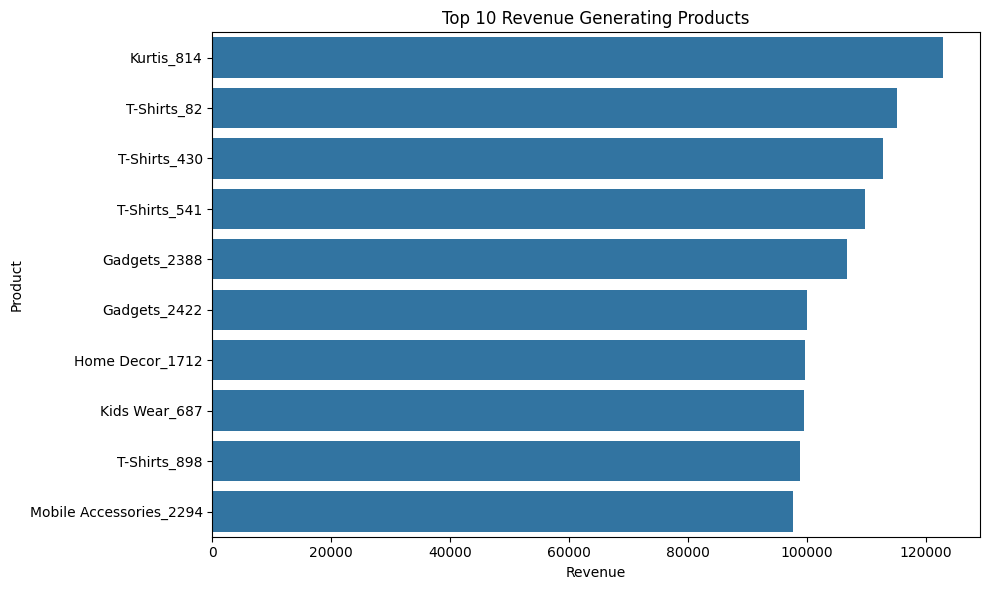

In [15]:
# ---------------------------------------------------
# SECTION 8: Top Products Visualization
# Purpose:
# Visualize the top 10 products contributing
# the most revenue.
# ---------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products,
    x="item_revenue",
    y="product_name"
)

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------
# SECTION 9: RFM Customer Segmentation
# Purpose:
# Segment customers based on Recency, Frequency,
# and Monetary value.
# ---------------------------------------------------

# Filter delivered orders only
rfm_orders = orders.loc[orders["order_status"] == "Delivered"].copy()

# Convert order_date to datetime
rfm_orders["order_date"] = pd.to_datetime(rfm_orders["order_date"])

# Define snapshot date (latest date in dataset)
snapshot_date = rfm_orders["order_date"].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = rfm_orders.groupby("customer_name").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,  # Recency
    "order_id": "count",                                     # Frequency
    "total_amount": "sum"                                    # Monetary
})

# Rename columns
rfm.columns = ["recency", "frequency", "monetary"]

# View result
rfm.head()

,recency,frequency,monetary
customer_name,,,
Customer_00001,529,2,2053.65
Customer_00002,103,3,9008.37
Customer_00003,214,2,3563.75
Customer_00004,120,2,2061.38
Customer_00005,59,3,5516.99


In [17]:
# ---------------------------------------------------
# SECTION 10: RFM Scoring
# Purpose:
# Convert recency, frequency and monetary values
# into scores from 1 to 5.
# ---------------------------------------------------

# Recency score (lower recency is better)
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])

# Frequency score (higher frequency is better)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])

# Monetary score (higher spending is better)
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

# Convert scores to integers
rfm["r_score"] = rfm["r_score"].astype(int)
rfm["f_score"] = rfm["f_score"].astype(int)
rfm["m_score"] = rfm["m_score"].astype(int)

# Create combined RFM score
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

# View result
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
customer_name,,,,,,,
Customer_00001,529,2,2053.65,1,2,1,4
Customer_00002,103,3,9008.37,4,4,4,12
Customer_00003,214,2,3563.75,2,2,2,6
Customer_00004,120,2,2061.38,4,2,1,7
Customer_00005,59,3,5516.99,4,4,3,11


In [18]:
# ---------------------------------------------------
# SECTION 11: Customer Segmentation
# Purpose:
# Classify customers into meaningful groups
# based on their RFM score.
# ---------------------------------------------------

def segment_customer(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 7:
        return "Potential Loyalists"

    elif score >= 5:
        return "At Risk"

    else:
        return "Lost Customers"


# Apply segmentation
rfm["segment"] = rfm["rfm_score"].apply(segment_customer)

# View result
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
customer_name,,,,,,,,
Customer_00001,529,2,2053.65,1,2,1,4,Lost Customers
Customer_00002,103,3,9008.37,4,4,4,12,Loyal Customers
Customer_00003,214,2,3563.75,2,2,2,6,At Risk
Customer_00004,120,2,2061.38,4,2,1,7,Potential Loyalists
Customer_00005,59,3,5516.99,4,4,3,11,Loyal Customers


In [19]:
# ---------------------------------------------------
# SECTION 12: Segment Distribution
# Purpose:
# Understand how many customers fall into
# each segment.
# ---------------------------------------------------

segment_counts = rfm["segment"].value_counts().reset_index()

segment_counts.columns = ["segment", "customer_count"]

segment_counts

,segment,customer_count
0,Loyal Customers,2750
1,Potential Loyalists,2722
2,Champions,1799
3,At Risk,1629
4,Lost Customers,1052


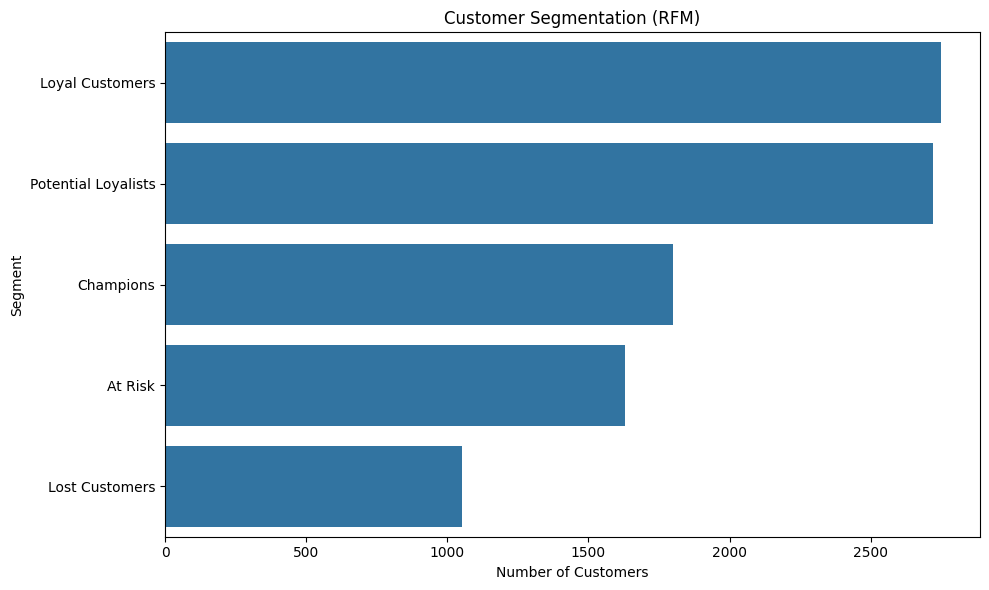

In [20]:
# ---------------------------------------------------
# SECTION 13: Customer Segment Chart
# Purpose:
# Visualize the distribution of customers
# across segments.
# ---------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_counts,
    x="customer_count",
    y="segment"
)

plt.title("Customer Segmentation (RFM)")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.tight_layout()

plt.show()

In [21]:
# ---------------------------------------------------
# SECTION 14: Cohort Analysis
# Purpose:
# Understand customer retention behavior
# by grouping customers based on their
# first purchase month.
# ---------------------------------------------------

# Convert order date again to ensure correct format
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Filter delivered orders
cohort_data = orders.loc[orders["order_status"] == "Delivered"].copy()

# Create order month column
cohort_data["order_month"] = cohort_data["order_date"].dt.to_period("M")

# Identify the first purchase month of each customer
cohort_data["cohort_month"] = cohort_data.groupby("customer_name")["order_month"].transform("min")

# View result
cohort_data.head()

,order_id,reseller_id,customer_name,order_date,delivery_date,city,state,order_status,total_amount,payment_method,order_month,cohort_month
0,1,125,Customer_04451,2024-01-31,2024-02-06,Agra,West Bengal,Delivered,1841.90,Wallet,2024-01,2023-09
1,2,573,Customer_11626,2023-03-18,2023-03-27,Agra,Maharashtra,Delivered,7948.32,Wallet,2023-03,2023-03
2,3,620,Customer_08833,2023-07-27,2023-08-03,Jaipur,Karnataka,Delivered,2714.00,COD,2023-07,2023-07
3,4,674,Customer_11111,2024-01-29,2024-02-04,Indore,Telangana,Delivered,2375.94,UPI,2024-01,2024-01
4,5,73,Customer_10443,2023-05-25,2023-06-03,Hyderabad,West Bengal,Delivered,1620.81,Wallet,2023-05,2023-04


In [22]:
# ---------------------------------------------------
# SECTION 15: Cohort Retention Table
# Purpose:
# Calculate how many customers return
# in later months after their first purchase.
# ---------------------------------------------------

# Calculate cohort index (months since first purchase)

cohort_data["cohort_index"] = (
    (cohort_data["order_month"] - cohort_data["cohort_month"])
    .apply(lambda x: x.n)
)

# Count customers per cohort
cohort_counts = cohort_data.groupby(
    ["cohort_month", "cohort_index"]
)["customer_name"].nunique().reset_index()

# Pivot table to create cohort matrix
cohort_pivot = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_name"
)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2023-01,1116.0,97.0,99.0,115.0,94.0,97.0,95.0,97.0,88.0,122.0,124.0,114.0,120.0,101.0,95.0,102.0,95.0,89.0
2023-02,935.0,91.0,85.0,85.0,84.0,96.0,95.0,72.0,87.0,95.0,105.0,89.0,78.0,95.0,66.0,112.0,92.0,NaN
2023-03,1001.0,98.0,92.0,106.0,72.0,84.0,112.0,91.0,89.0,96.0,105.0,78.0,92.0,81.0,107.0,90.0,NaN,NaN
2023-04,852.0,95.0,92.0,89.0,80.0,81.0,76.0,68.0,70.0,95.0,73.0,76.0,87.0,80.0,76.0,NaN,NaN,NaN
2023-05,766.0,80.0,83.0,67.0,83.0,81.0,79.0,78.0,65.0,75.0,68.0,64.0,62.0,71.0,NaN,NaN,NaN,NaN


In [23]:
# ---------------------------------------------------
# SECTION 16: Cohort Retention Percentage
# Purpose:
# Convert counts into percentage retention.
# ---------------------------------------------------

cohort_sizes = cohort_pivot.iloc[:,0]

retention = cohort_pivot.divide(cohort_sizes, axis=0)

retention.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2023-01,1.0,0.086918,0.088710,0.103047,0.084229,0.086918,0.085125,0.086918,0.078853,0.109319,0.111111,0.102151,0.107527,0.090502,0.085125,0.091398,0.085125,0.079749
2023-02,1.0,0.097326,0.090909,0.090909,0.089840,0.102674,0.101604,0.077005,0.093048,0.101604,0.112299,0.095187,0.083422,0.101604,0.070588,0.119786,0.098396,NaN
2023-03,1.0,0.097902,0.091908,0.105894,0.071928,0.083916,0.111888,0.090909,0.088911,0.095904,0.104895,0.077922,0.091908,0.080919,0.106893,0.089910,NaN,NaN
2023-04,1.0,0.111502,0.107981,0.104460,0.093897,0.095070,0.089202,0.079812,0.082160,0.111502,0.085681,0.089202,0.102113,0.093897,0.089202,NaN,NaN,NaN
2023-05,1.0,0.104439,0.108355,0.087467,0.108355,0.105744,0.103133,0.101828,0.084856,0.097911,0.088773,0.083551,0.080940,0.092689,NaN,NaN,NaN,NaN


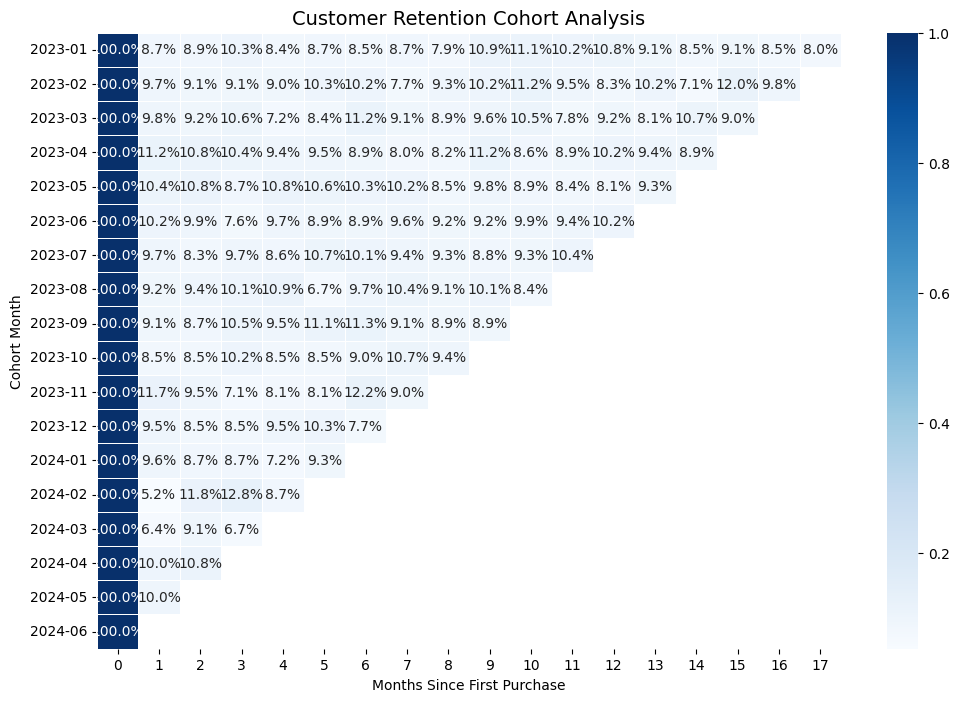

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Customer Retention Cohort Analysis", fontsize=14)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [25]:
# ---------------------------------------------------
# SECTION 18: Customer Purchase Frequency
# Purpose:
# Understand how many orders each customer makes.
# ---------------------------------------------------

customer_orders = orders.groupby("customer_name")["order_id"].count().reset_index()

customer_orders.columns = ["customer_name", "order_count"]

customer_orders.head()

,customer_name,order_count
0,Customer_00001,2
1,Customer_00002,3
2,Customer_00003,2
3,Customer_00004,3
4,Customer_00005,3


In [26]:
# Count how many customers fall into each purchase bucket
purchase_distribution = customer_orders["order_count"].value_counts().sort_index()

purchase_distribution

order_count
1    3130
2    3176
3    2258
4    1205
5     490
6     177
7      41
8      10
9       5
Name: count, dtype: int64

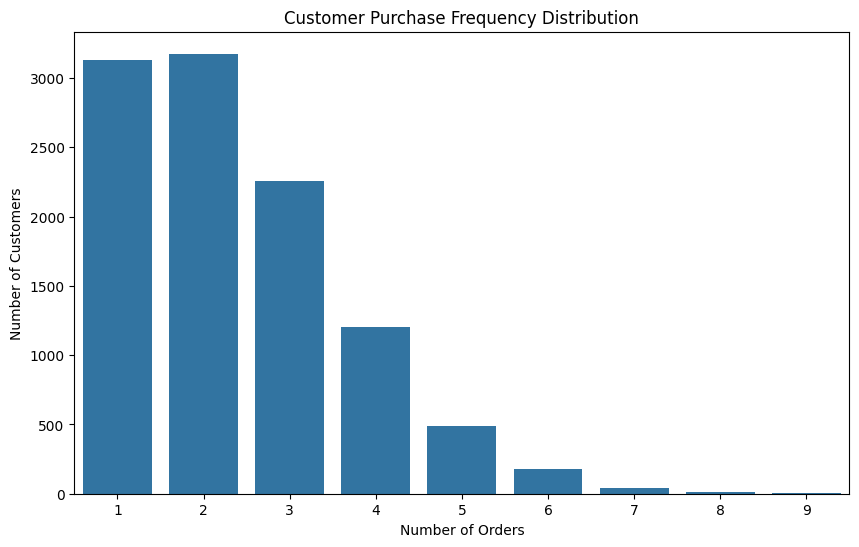

In [30]:
# ---------------------------------------------------
# SECTION 19: Purchase Frequency Chart
# Purpose:
# Visualize how often customers buy.
# ---------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x=purchase_distribution.index.astype(int),
    y=purchase_distribution.values
)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
orders["customer_name"].nunique()

10492